In [1]:
# ── Heart Failure Clinical Data ───────────────────────────────────────────────
# Source: https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data
# Task:   Predict heart failure mortality risk
# File:   heart_failure_clinical_records_dataset.csv
# ─────────────────────────────────────────────────────────────────────────────

# TODO: import any additional libraries you need
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
df.head()

Shape: (299, 13)

Columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data types:
 age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
# Quick look — run this before anything else
print("Missing values:")
print(df.isnull().sum())

print("\nTarget distribution (DEATH_EVENT):")
print(df['DEATH_EVENT'].value_counts())
print(f"Mortality rate: {df['DEATH_EVENT'].mean():.1%}")

# Things to think about:
# - Only 299 rows — how does that affect your modeling choices?
# - The 'time' column is follow-up duration. Should you use it as a feature?

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Target distribution (DEATH_EVENT):
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
Mortality rate: 32.1%


In [4]:
# ── EDA ───────────────────────────────────────────────────────────────────────
# TODO: explore the data
# Ideas:
# - Plot distributions of ejection_fraction, serum_creatinine, age
# - Boxplots comparing survivors vs non-survivors across key features
# - Correlation heatmap

# your code here

In [5]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
# TODO: prepare data for modeling
# Things to consider:
# - No missing values — lucky!
# - Feature scaling (important for some models)
# - Include or exclude 'time'? Why?
# - Small dataset — consider cross-validation over a single train/test split

# your code here

# Validate Columns
req_cols = {'age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT'}
if not req_cols.issubset(df.columns):
    raise ValueError("Missing required columns")

df.fillna(0, inplace=True)

if 'patient_id' in df.columns:
    df.drop(columns=['patient_id'], inplace=True)

# Generate all IDs at once instead of one at a time
df.insert(0, 'patient_id', [f'P{i:06d}' for i in range(len(df))])

print(f"Preprocessed {len(df)} patients.")
df.head()

Preprocessed 299 patients.


,patient_id,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,P000000,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,P000001,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,P000002,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,P000003,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,P000004,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
# ── Model ─────────────────────────────────────────────────────────────────────
# TODO: build and train your model

# your code here

# Define feature matrix + target
FEATURES = [
    'age',
    'anaemia',
    'creatinine_phosphokinase',
    'diabetes',
    'ejection_fraction',
    'high_blood_pressure',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'sex',
    'smoking'
]

TARGET = 'DEATH_EVENT'

X = df[FEATURES]
y = df[TARGET]

# Only put scaler on training folds
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, 
                                       class_weight='balanced',
                                       max_depth=3,
                                       min_samples_leaf=15,
                                       random_state=42))
])

pipeline.fit(X, y)

with open('pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

In [8]:
# ── Evaluation ────────────────────────────────────────────────────────────────
# TODO: evaluate your model
# Suggested metrics:
# - ROC-AUC
# - Precision, Recall, F1
# - Confusion matrix

# Bonus: try building a model using ONLY serum_creatinine + ejection_fraction
# The reference paper found these two features alone predict survival well

# Discussion:
# - How does your AUC compare to random guessing (0.5)?
# - What are the risks of drawing conclusions from only 299 patients?

# your code here

# Do multiple cross-validation rounds
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
results = cross_validate(
    pipeline, X, y,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1', 'precision', 'recall'],
    return_train_score=True
)

metrics = {
    'Accuracy': results['test_accuracy'],
    'ROC-AUC': results['test_roc_auc'],
    'F1 Score': results['test_f1'],
    'Precision': results['test_precision'],
    'Recall': results['test_recall']
}

# Save metrics to a CSV
gap = results['train_accuracy'].mean() - results['test_accuracy'].mean()
metrics_rows = []

for metric, scores in metrics.items():
    metrics_rows.append({
        'Metric':   metric,
        'Mean':     round(scores.mean(), 3),
        'Std':      round(scores.std(), 3),
        'Min':      round(scores.min(), 3),
        'Max':      round(scores.max(), 3)
    })

metrics_rows.append({
    'Metric': 'Overfitting Gap',
    'Mean':   round(gap, 3),
    'Std':    None,
    'Min':    None,
    'Max':    None
})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv('metrics.csv', index=False)

Feature Importance (by model contribution)

 Rank                  Feature  Importance
    1         serum_creatinine    0.375663
    2        ejection_fraction    0.238048
    3                      age    0.156739
    4             serum_sodium    0.089363
    5 creatinine_phosphokinase    0.051624
    6                platelets    0.046419
    7                      sex    0.010965
    8      high_blood_pressure    0.010869
    9                  anaemia    0.009385
   10                  smoking    0.005625
   11                 diabetes    0.005300

Saved to feature_importance.csv


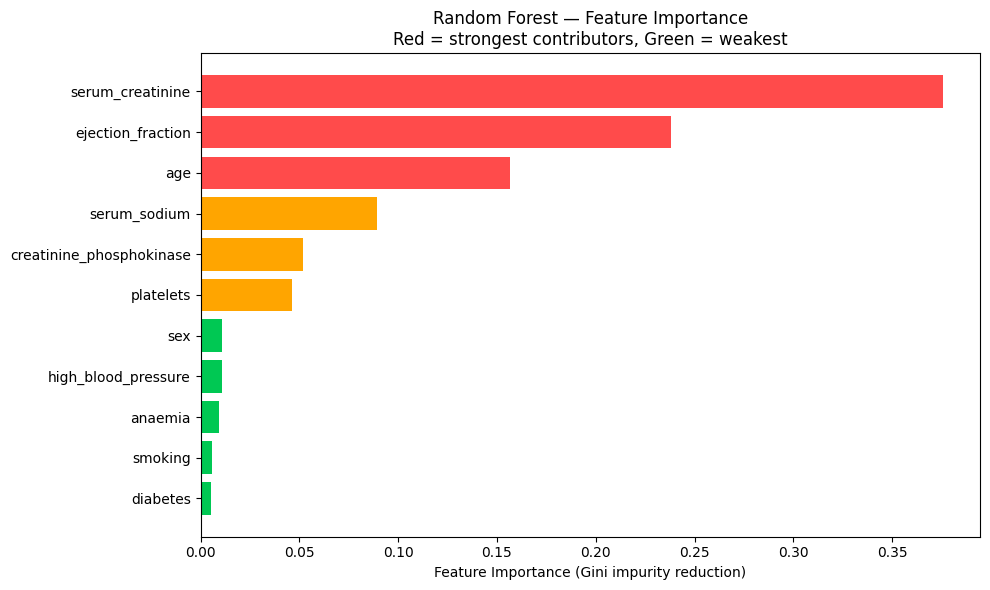

In [9]:
# ── Feature Importance ────────────────────────────────────────────────────────
# Extracted from Random Forest's built-in feature_importances_
# Values represent how much each feature reduces impurity across all trees.
# Higher = more influential in predictions. Does not imply clinical causation.

model_step = pipeline.named_steps['model']

importance_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': model_step.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Add rank
importance_df.insert(0, 'Rank', range(1, len(importance_df) + 1))

print("Feature Importance (by model contribution)\n")
print(importance_df.to_string(index=False))

# Save for UI
importance_df.to_csv('feature_importance.csv', index=False)
print("\nSaved to feature_importance.csv")

# Chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    '#FF4B4B' if i < 3 else
    '#FFA500' if i < 6 else
    '#00C853'
    for i in range(len(importance_df))
]

ax.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1],
    color=colors[::-1]
)

ax.set_xlabel('Feature Importance (Gini impurity reduction)')
ax.set_title('Random Forest — Feature Importance\n'
             'Red = strongest contributors, Green = weakest')
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [10]:
# ── Similar Patients ─────────────────────────────────────────────────────────────
# Finds patients with similar statistics to a given patient
# Also summarizes the outcomes of similar parents
def find_similar_patients(patient, df, top_n):
    continuous = [
        'age', 'creatinine_phosphokinase', 'ejection_fraction',
        'platelets', 'serum_creatinine', 'serum_sodium'
    ]
    boolean = [
        'anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking'
    ]

    # Normalize continuous features to 0-1 for fair distance comparison
    df_norm = df.copy()
    patient_norm = {}

    for col in continuous:
        col_min = df[col].min()
        col_max = df[col].max()
        df_norm[col] = (df[col] - col_min) / (col_max - col_min)
        patient_norm[col] = (patient[col] - col_min) / (col_max - col_min)

    for col in boolean:
        patient_norm[col] = patient[col]

    # Calculate Euclidean distance from patient to every row
    all_features = continuous + boolean
    distances = np.sqrt(
        sum((df_norm[col] - patient_norm[col]) ** 2 for col in all_features)
    )

    df_norm['distance'] = distances

    # Return top N most similar patients with their time + outcome
    similar = df.loc[df_norm['distance'].nsmallest(top_n).index]
    return similar[['time', 'DEATH_EVENT', 'ejection_fraction', 
                     'serum_creatinine', 'age']]

def summarize_survival(similar_patients: pd.DataFrame) -> dict:
    """
    Summarize what happened to similar patients over time.
    """
    died     = similar_patients[similar_patients['DEATH_EVENT'] == 1]
    survived = similar_patients[similar_patients['DEATH_EVENT'] == 0]

    result = {
        "similar_patients_count": len(similar_patients),
        "died_count":             len(died),
        "survived_count":         len(survived),
        "mortality_rate":         f"{len(died) / len(similar_patients) * 100:.0f}%",
    }

    if len(died) > 0:
        result["avg_days_to_death"] = round(died['time'].mean())
        result["min_days_to_death"] = int(died['time'].min())
        result["max_days_to_death"] = int(died['time'].max())
    else:
        result["avg_days_to_death"] = None

    if len(survived) > 0:
        result["avg_followup_survived"] = round(survived['time'].mean())

    return result

In [11]:
# ── Recommendation Logic ─────────────────────────────────────────────────────────────
# Sort patient into risk category
def get_risk_category(risk_prob):
    if risk_prob >= 0.7:
        return {
            "category": "CRITICAL",
            "label": "Critical Risk",
            "urgency": "critical"
        }
    elif risk_prob >= 0.4:
        return {
            "category": "MODERATE",
            "label": "Moderate Risk",
            "urgency": "moderate"
        }
    else:
        return {
            "category": "LOW",
            "label": "Low Risk",
            "urgency": "low"
        }

# Generate a list of risk factors depending on patient metrics
def get_risk_factors(patient: dict) -> list:
    flags = {}  # dict so we can rank by feature name later

    if patient['ejection_fraction'] < 40:
        flags['ejection_fraction'] = (
            f"Low ejection fraction ({patient['ejection_fraction']}%) — "
            f"heart pumping below normal range"
        )
    if patient['serum_creatinine'] > 2.0:
        flags['serum_creatinine'] = (
            f"Elevated serum creatinine ({patient['serum_creatinine']} mg/dL) — "
            f"above normal range, associated with kidney stress"
        )
    if patient['age'] > 70:
        flags['age'] = (
            f"Age {int(patient['age'])} — "
            f"older age is associated with higher cardiac risk"
        )
    if patient['serum_sodium'] < 130:
        flags['serum_sodium'] = (
            f"Low serum sodium ({patient['serum_sodium']} mEq/L) — "
            f"below normal range, associated with fluid retention"
        )
    if patient['diabetes'] == 1:
        flags['diabetes'] = (
            "Diabetes present — associated with increased cardiovascular risk"
        )
    if patient['high_blood_pressure'] == 1:
        flags['high_blood_pressure'] = (
            "High blood pressure present — associated with increased cardiac strain"
        )
    if patient['anaemia'] == 1:
        flags['anaemia'] = (
            "Anaemia present — associated with reduced oxygen delivery"
        )
    if patient['creatinine_phosphokinase'] > 1000:
        flags['creatinine_phosphokinase'] = (
            f"Elevated CPK ({patient['creatinine_phosphokinase']} U/L) — "
            f"above normal range, associated with muscle stress"
        )
    if patient['smoking'] == 1:
        flags['smoking'] = (
            "Smoking present — associated with accelerated arterial damage"
        )
    if patient['platelets'] < 100000:
        flags['platelets'] = (
            f"Low platelets ({patient['platelets']:.0f}/µL) — below normal range"
        )
    elif patient['platelets'] > 600000:
        flags['platelets'] = (
            f"High platelets ({patient['platelets']:.0f}/µL) — "
            f"above normal range, associated with clotting risk"
        )

    if not flags:
        return []

    # Rank flagged features by model importance
    try:
        importance_df  = pd.read_csv('feature_importance.csv')
        importance_map = dict(zip(importance_df['Feature'], importance_df['Importance']))
        ranked = sorted(
            flags.items(),
            key=lambda x: importance_map.get(x[0], 0),
            reverse=True
        )
    except FileNotFoundError:
        importance_map = {}
        ranked = list(flags.items())

    return [
        {
            "feature":     feature,
            "description": description,
            "importance":  importance_map.get(feature, 0)
        }
        for feature, description in ranked
    ]

# Recommend a course of action based on their category
def get_recommendation(risk_category: dict, survival: dict,
                        risk_factors: list) -> dict:
    """
    Map risk category + survival stats + risk factors
    to a full recommendation object for the UI.
    """
    category  = risk_category["category"]
    avg_days  = survival.get("avg_days_to_death")
    mort_rate = survival["mortality_rate"]
    factors_text = "; ".join(f["description"] for f in risk_factors)

    if category == "CRITICAL":
        title   = "⛔ Admit Immediately"
        summary = (
            f"This patient is at critical risk of mortality. "
            f"{mort_rate} of similar patients died"
            + (f", on average within {avg_days} days." if avg_days else ".")
        )
        action  = (
            "Immediate admission and intervention is strongly recommended. "
            "Do not discharge without cardiology review."
        )

    elif category == "MODERATE":
        title   = "⚠️ Monitor Closely"
        summary = (
            f"This patient shows moderate mortality risk. "
            f"{mort_rate} of similar patients died"
            + (f", typically within {avg_days} days." if avg_days else ".")
        )
        action  = (
            "Schedule follow-up within 7 days. Monitor serum creatinine "
            "and ejection fraction closely. Consider cardiology referral."
        )

    else:
        survived = survival.get("avg_followup_survived", "N/A")
        title    = "✅ Routine Care"
        summary  = (
            f"This patient is currently low risk. "
            f"{survival['survived_count']} of {survival['similar_patients_count']} "
            f"similar patients survived with an average follow-up of "
            f"{survived} days."
        )
        action   = (
            "Continue routine monitoring. Reassess if symptoms worsen "
            "or new risk factors emerge."
        )

    return {
        "title":        title,
        "summary":      summary,
        "action":       action,
        "risk_factors": risk_factors,
        "factors_text": factors_text
    }


def predict_patient(patient: dict) -> dict:
    df_input       = pd.DataFrame([patient])[FEATURES]
    risk_prob      = pipeline.predict_proba(df_input)[0][1]
    risk_category  = get_risk_category(risk_prob)
    risk_factors   = get_risk_factors(patient)
    similar        = find_similar_patients(patient, df, top_n=10)
    survival       = summarize_survival(similar)
    recommendation = get_recommendation(risk_category, survival, risk_factors)

    return {
        "mortality_risk":   f"{risk_prob * 100:.1f}%",
        "risk_category":    risk_category,
        "risk_factors":     risk_factors,
        "similar_patients": survival,
        "recommendation":   recommendation
    }

In [12]:
# ── Prediction Pipeline ───────────────────────────────────────────────────────
# Generates mortality risk predictions for all patients in the dataset

X_all = df[FEATURES]

# Generate probabilities and labels for every patient
probabilities    = pipeline.predict_proba(X_all)[:, 1]
predicted_labels = pipeline.predict(X_all)

# Build output dataframe
predictions_df = pd.DataFrame({
    'patient_id':      df['patient_id'].values,
    'probability':     probabilities.round(4),
    'predicted_label': predicted_labels,
    'DEATH_EVENT':     df['DEATH_EVENT'].values
})

# Verify no NaN values
assert predictions_df.isnull().sum().sum() == 0, "NaN values found in predictions"
assert len(predictions_df) == len(df),           "Row count mismatch"

print(f"Predictions generated: {len(predictions_df)} patients")
print(f"NaN values:            {predictions_df.isnull().sum().sum()}")
print(f"High risk patients:    {(predicted_labels == 1).sum()}")
print(f"Low risk patients:     {(predicted_labels == 0).sum()}")

predictions_df.to_csv('predictions.csv', index=False)
print("Saved to predictions.csv")

predictions_df.head(10)

Predictions generated: 299 patients
NaN values:            0
High risk patients:    110
Low risk patients:     189
Saved to predictions.csv


,patient_id,probability,predicted_label,DEATH_EVENT
0,P000000,0.8375,1,1
1,P000001,0.3338,0,1
2,P000002,0.6801,1,1
3,P000003,0.7138,1,1
4,P000004,0.7852,1,1
5,P000005,0.7235,1,1
6,P000006,0.6910,1,1
7,P000007,0.4224,0,1
8,P000008,0.4117,0,1
9,P000009,0.7495,1,1


In [13]:
# ── Prediction Demo ───────────────────────────────────────────────────────
# Testing predict_patient on an example
example_patient = {
    "age": 65,
    "anaemia": 1,
    "creatinine_phosphokinase": 250,
    "diabetes": 1,
    "ejection_fraction": 35,
    "high_blood_pressure": 1,
    "platelets": 200000,
    "serum_creatinine": 1.9,
    "serum_sodium": 130,
    "sex": 1,
    "smoking": 0
}

result = predict_patient(example_patient)

print(f"Mortality Risk:  {result['mortality_risk']}")
print(f"Risk Category:   {result['risk_category']['label']}")
print(f"\n{result['recommendation']['title']}")
print(f"{result['recommendation']['summary']}")
print(f"{result['recommendation']['action']}")

print(f"\nTop Risk Drivers (ranked by model importance):")
if result['risk_factors']:
    for i, factor in enumerate(result['risk_factors'], 1):
        print(f"  {i}. {factor['description']}  "
              f"(importance: {factor['importance']:.4f})")
else:
    print("  No individual risk factors flagged")

Mortality Risk:  69.7%
Risk Category:   Moderate Risk

⚠️ Monitor Closely
This patient shows moderate mortality risk. 20% of similar patients died, typically within 128 days.
Schedule follow-up within 7 days. Monitor serum creatinine and ejection fraction closely. Consider cardiology referral.

Top Risk Drivers (ranked by model importance):
  1. Low ejection fraction (35%) — heart pumping below normal range  (importance: 0.2380)
  2. High blood pressure present — associated with increased cardiac strain  (importance: 0.0109)
  3. Anaemia present — associated with reduced oxygen delivery  (importance: 0.0094)
  4. Diabetes present — associated with increased cardiovascular risk  (importance: 0.0053)
